In [1]:
import os
os.getcwd()

'C:\\Users\\jhood\\OneDrive\\Desktop\\data-portfolio\\projects\\marketing-analytics'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup works!")

Setup works!


In [36]:
import pandas as pd

df = pd.read_csv('data/marketing_campaign.csv', sep=';')

In [37]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [38]:
df['Total_Spend'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

In [39]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total_Spend
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,3,11,0,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,3,11,0,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,3,11,0,422


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [41]:
df.columns = df.columns.str.strip()

In [42]:
df['Total_Spend'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

In [43]:
df['Age'] = 2026 - df['Year_Birth']

In [44]:
df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

In [45]:
df['Avg_Order_Value'] = df['Total_Spend'] / df['Total_Purchases']

In [46]:
df['Response'].mean()

np.float64(0.14910714285714285)

In [47]:
df['Total_Spend'].mean()

np.float64(605.7982142857143)

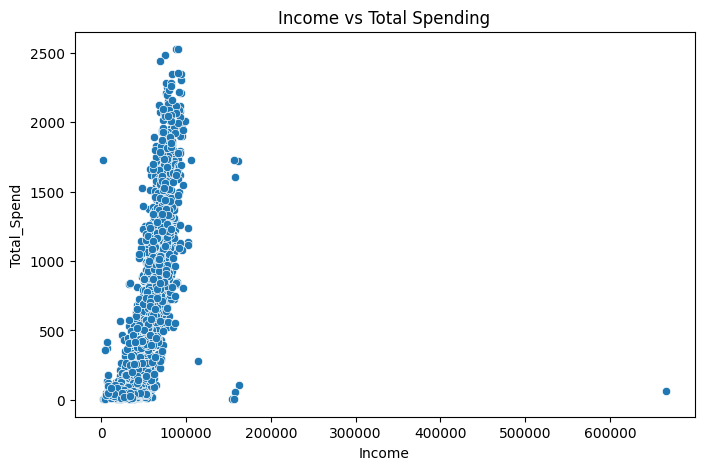

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Income', y='Total_Spend')
plt.title("Income vs Total Spending")
plt.show()

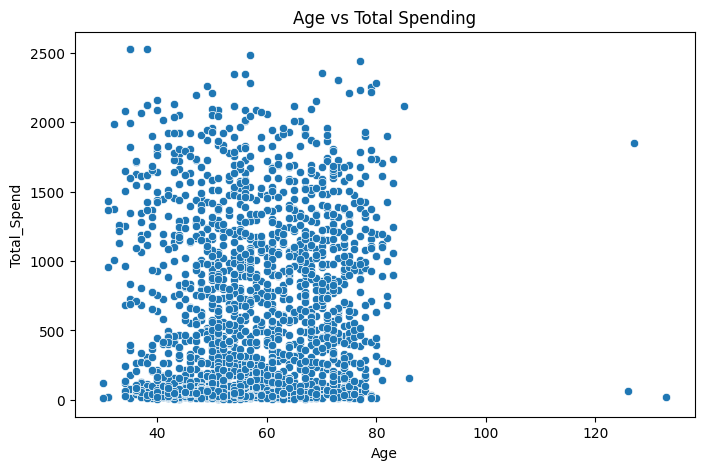

In [49]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Age', y='Total_Spend')
plt.title("Age vs Total Spending")
plt.show()

In [51]:
df[['Income', 'Total_Spend']].isnull().sum()

Income         24
Total_Spend     0
dtype: int64

In [52]:
df_clean = df[['Income', 'Total_Spend']].dropna()

In [53]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

df.loc[df_clean.index, 'Segment'] = kmeans.fit_predict(df_clean)

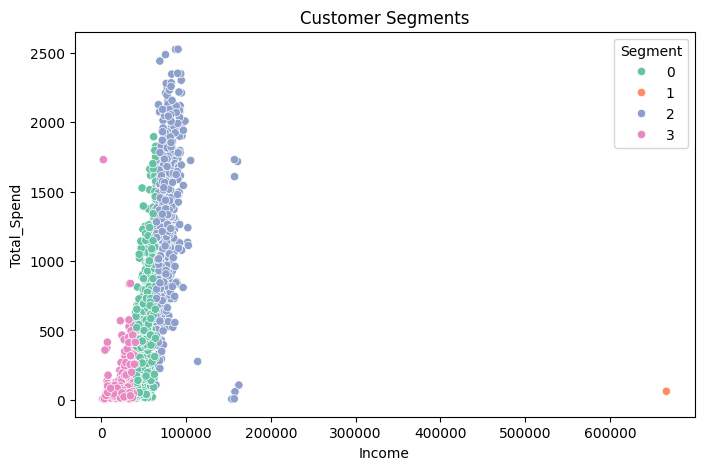

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Income',
    y='Total_Spend',
    hue='Segment',
    palette='Set2'
)
plt.title("Customer Segments")
plt.show()

In [57]:
df[['Income', 'Total_Spend']].isnull().sum()

Income         24
Total_Spend     0
dtype: int64

In [58]:
df['Segment'].value_counts()

Segment
0    810
3    737
2    692
1      1
Name: count, dtype: int64

In [59]:
df.groupby('Segment')[['Income', 'Total_Spend', 'Age']].mean()

,Income,Total_Spend,Age
Segment,,,
0,52250.377863,492.332099,59.920988
1,666666.000000,62.000000,49.000000
2,76878.028902,1283.527457,58.592486
3,28283.378562,94.892809,52.895522


In [60]:
def label_segment(row):
    if row['Income'] > df['Income'].median() and row['Total_Spend'] > df['Total_Spend'].median():
        return "High Value"
    elif row['Income'] > df['Income'].median():
        return "High Income - Low Spend"
    elif row['Total_Spend'] > df['Total_Spend'].median():
        return "Low Income - High Spend"
    else:
        return "Low Value Customers"

In [61]:
df['Segment_Label'] = df.apply(label_segment, axis=1)

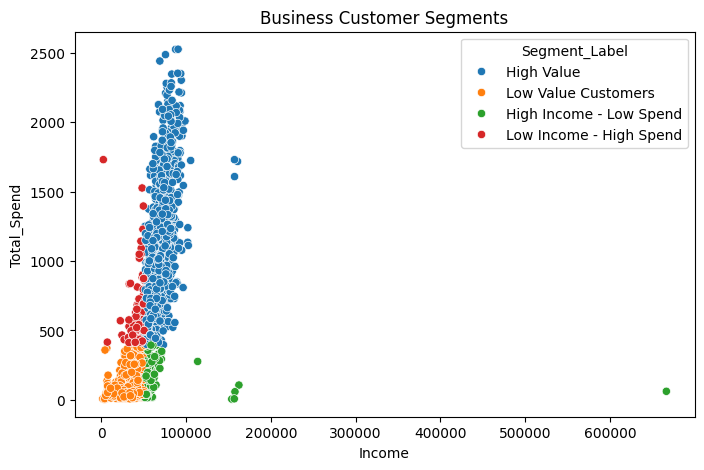

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Income',
    y='Total_Spend',
    hue='Segment_Label'
)
plt.title("Business Customer Segments")
plt.show()

In [63]:
df.groupby('Segment_Label')[['Income', 'Total_Spend']].mean()

,Income,Total_Spend
Segment_Label,,
High Income - Low Spend,66027.584000,204.168000
High Value,70923.191251,1166.232960
Low Income - High Spend,43730.320000,625.352941
Low Value Customers,32902.008138,100.413655
